# Stanford CME 241 (Winter 2026) - Assignment 2

**Due: Friday, February 13 @ 11:59 PM PST on Gradescope.**

Assignment instructions:
- Make sure each of the subquestions have answers
- Ensure that group members indicate which problems they're in charge of
- Show work and walk through your thought process where applicable
- Empty code blocks are for your use, so feel free to create more under each section as needed
- Document code with light comments (i.e. 'this function handles visualization')

Submission instructions:
- When complete, fill out your publicly available GitHub repo file URL and group members below, then export or print this .ipynb file to PDF and upload the PDF to Gradescope.

*Link to this ipynb file in your public GitHub repo (replace below URL with yours):* 

https://github.com/jrothkow/cme241/blob/main/assignment2.ipynb

*Group members (replace below names with people in your group):* 
- Jordan Rothkowitz
- Lucas Tellez

## Imports

In [97]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.typing as npt
from math import factorial
from scipy.stats import poisson
from tqdm import trange
import pandas as pd
from scipy.stats import pearsonr
import statsmodels.api as sm

## Question 1: Job-Hopping and Wages-Utility-Maximization (Led by Lucas Tellez)

You are a worker who starts every day either employed or unemployed. If you start your day employed, you work on your job for the day (one of $n$ jobs, as elaborated later) and you get to earn the wage of the job for the day. However, at the end of the day, you could lose your job with probability $\alpha \in [0,1]$, in which case you start the next day unemployed. If at the end of the day, you do not lose your job (with probability $1-\alpha$), then you will start the next day with the same job (and hence, the same daily wage). 

On the other hand, if you start your day unemployed, then you will be randomly offered one of $n$ jobs with daily wages $w_1, w_2, \ldots w_n \in \mathbb{R}^+$ with respective job-offer probabilities $p_1, p_2, \ldots p_n \in [0,1]$ (with $\sum_{i=1}^n p_i = 1$). You can choose to either accept or decline the offered job. If you accept the job offer, your day progresses exactly like the **employed-day** described above (earning the day's job wage and possibly (with probability $\alpha$) losing the job at the end of the day). However, if you decline the job offer, you spend the day unemployed, receive the unemployment wage $w_0 \in \mathbb{R}^+$ for the day, and start the next day unemployed.

The problem is to identify the optimal choice of accepting or rejecting any of the job offers the worker receives, in a manner that maximizes the infinite-horizon **Expected Discounted-Sum of Wages Utility**. Assume the daily discount factor for wages (employed or unemployed) is $\gamma \in [0,1])$. Assume Wages Utility function to be $U(w) = \log(w)$ for any wage amount $w \in \mathbb{R}^+$. The goal is to maximize:

$$
\mathbb{E}\left[\sum_{u=t}^\infty \gamma^{u-t} \cdot \log(w_{i_u})\right]
$$

at the start of a given day $t$ ($w_{i_u}$ is the wage earned on day $u$, $0 \leq i_u \leq n$ for all $u \geq t$).

---

### Subquestions

#### Part (A): MDP Modeling

Express the job-hopping problem as an MDP using clear mathematical notation by defining the following components:

1. **State Space**: Define the possible states of the MDP.
2. **Action Space**: Specify the actions available to the worker at each state.
3. **Transition Function**: Describe the probabilities of transitioning between states for each action.
4. **Reward Function**: Specify the reward associated with the states and transitions.
5. **Bellman Optimality Equation**: Write the Bellman Optimality Equation customized for this MDP.

---

#### Part (B): Python Implementation

Write Python code that:

1. Solves the Bellman Optimality Equation (hence, solves for the **Optimal Value Function** and the **Optimal Policy**) with a numerical iterative algorithm. 
2. Clearly define the inputs and outputs of your algorithm with their types (`int`, `float`, `List`, `Mapping`, etc.).

*Note*: For this problem, write the algorithm from scratch without using any prebuilt MDP/DP libraries or code.

---

#### Part (C): Visualization and Analysis

1. Plot the **Optimal Value Function** as a function of the state for a specific set of parameters ($n$, $w_1, \ldots, w_n$, $p_1, \ldots, p_n$, $\alpha$, $\gamma$, $w_0$).
2. Include these graphs in your submission.

---

#### Part (D): Observations

1. What patterns do you observe in the **Optimal Policy** as you vary the parameters $n$, $\alpha$, and $\gamma$?
2. Provide a brief discussion of your findings.

---

### Part (A) Answer

The state space is defined as $\mathcal S := \{0,1\}\times\{1,...,n\}$ which represents whether you begin unemployed (first coordinate is zero) or employed (first coordinate is one) and the job you are offered in the morning (second coordinate which is trivial if you are employed).
The action space is either Boolean or trivial, depending on employment, i.e 
$$
\mathcal A_{e,j} :=
\begin{cases} 
\{0,1\} : & e = 0\\
\{1\} : & e = 1
\end{cases}
$$ where 0 corresponds to rejecting the given job offer and 1 corresponds to accepting the job offer (or working at your current job by default).
We can express the transition probabilities as 
$$
p((e,i),a,(f,j)) := \begin{cases}
1 - \alpha : & i = j \ , \ a = f = 1\\
\alpha p_j : & f = 0 \ , \ a = 1\\
p_j : & e = f = 0 \ , \ a = 0\\
\end{cases}
$$
The reward is given by 
$$
R((e,j),a) := \begin{cases}
w_0 : & a = e = 0\\
w_j : & \text{otherwise}
\end{cases}
$$
The Bellman Optimality Equation here gives 
$$
V^*(e,j) = \begin{cases}
\max_{a \in \{0,1\}} \bigg[ 1_{a = 0} w_0 + 1_{a=0}\gamma\sum_{i=1}^n p_i V^*(0,i) + 1_{a = 1} w_j + 1_{a = 1}\gamma(1-\alpha)V^*(1,j) + 1_{a= 1}\gamma\alpha\sum_{i=1}^n p_i V^*(0,i)   \bigg] : & e = 0\\
w_j + \gamma (1-\alpha) V^*(1,j) + \gamma \alpha \sum_{i=1}^n p_i V^*(0,i)  : & e = 1
\end{cases}
$$

### Part (B) Answer

In [98]:
def ValueIteration(p: npt.NDArray[np.float64],w: npt.NDArray[np.float64],alpha: float, gamma: float,maxiter=100000,tol=1e-6):
    """
    p is a (n) numpy array of floats representing probabilities (should sum to 1 and be nonnegative)
    w is a (n+1) numpy array of floats (wages)
    alpha, gamma in (0,1)
    """
    V0 = np.random.rand(2, len(p))
    V = np.empty(V0.shape)
    assert np.all(w > 0)
    w = np.log(w)
    conv = False
    for iter in range(maxiter):
        V[1] = w[1:] + gamma * (1-alpha) * V0[1] + gamma * alpha * np.dot(p,V0[0])
        V[0] = np.maximum(w[0] + gamma * np.dot(p,V0[0]) * np.ones(len(p)), w[1:] + gamma * (1-alpha)*V0[1] + gamma * alpha * np.dot(p,V0[0]) )
        delta = np.max(np.abs(V - V0))
        if delta < tol:
            conv = True
            break
        V0 = V.copy()
    if not conv:
        print("Did not converge")
    Pi = np.ones(V.shape,dtype=int)
    Pi[0] = np.argmax(np.vstack([(w[0] + gamma * np.dot(p,V[0])) * np.ones(len(p)), w[1:] + gamma * (1-alpha)*V[1] + gamma * alpha * np.dot(p,V[0])]),axis=0 )
    return V,Pi


### Part (C) Answer

As a reasonable case study, I am choosing $n = 50$, $w_0 = 1$, $\gamma = 0.98$, $\alpha = 0.06$, and choosing w and p uniformly as follows:

In [99]:
n = 50
gamma = 0.98
alpha = 0.06
p = np.ones(n) / n
w = 1.0 + 10 * np.random.rand(n+1)
w[0] = 1.0
w.sort()
# sorted wages so that the plot has wages increasing in the x-axis

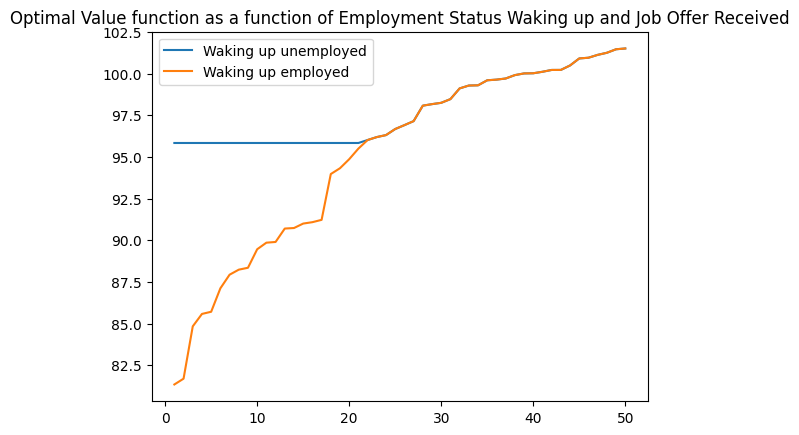

In [100]:
V,Pi = ValueIteration(p,w,0.1,0.98)
plt.plot(np.arange(1,n+1),V[0],label="Waking up unemployed")
plt.plot(np.arange(1,n+1),V[1],label="Waking up employed")
plt.title("Optimal Value function as a function of Employment Status Waking up and Job Offer Received")
plt.legend()

### Part (D) Answer
In the above experiment I sampled job offer probabilites uniformly, and wages as before many times for each value $\gamma,\alpha,n$ over a grid, in each sample finding $r$, the proportion of jobs for which a job offer was taken when waking up unemployed (waking up employed has only one action). I then marginalized 2 variables out at a time to isolate and plot the average relation between $r$ and each of the variables $\gamma,\alpha,n$. I also ran t-tests on each variable (Bonferroni corrected) to check that indeed each variable had statistically significant correlation with $r$. The results show that $\alpha$ is positively correlated with $r$, while $\gamma,n$ are negatively correlated with $r$.


Loop 6: 100%|██████████| 9/9 [01:43<00:00, 11.49s/it]


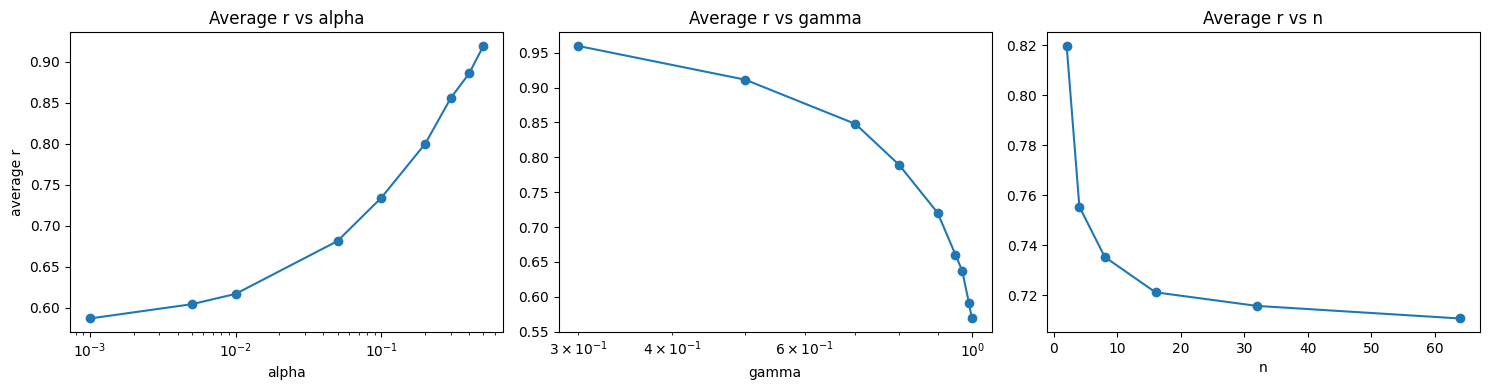

In [106]:
N = [2,4,8,16,32,64]
A = [0.001,0.005,0.01,0.05,0.1,0.2,0.3,0.4,0.5]
G = [0.999,0.99,0.97,0.95,0.9,0.8,0.7,0.5,0.3]

num_samples = 20

records = []
count = 0
for n in N:
    count += 1
    for j in trange(len(A),desc=f'Loop {count}'):
        alpha = A[j]
        for gamma in G:
            for _ in range(num_samples):
                p = np.random.rand(n)
                p = p / p.sum()
                w = 1.0 + 10 * np.random.rand(n + 1)
                w[0] = 1.0

                V, Pi = ValueIteration(p, w, alpha, gamma)
                r = np.count_nonzero(Pi[0]) / len(Pi[0])

                records.append({
                    "alpha": alpha,
                    "gamma": gamma,
                    "n": n,
                    "r": r
                })
df = pd.DataFrame(records)

avg_alpha = df.groupby("alpha", as_index=False)["r"].mean()
avg_gamma = df.groupby("gamma", as_index=False)["r"].mean()
avg_n     = df.groupby("n", as_index=False)["r"].mean()

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(avg_alpha["alpha"], avg_alpha["r"], marker="o")
axs[0].set_title("Average r vs alpha")
axs[0].set_xlabel("alpha")
axs[0].set_ylabel("average r")
axs[0].set_xscale('log')

axs[1].plot(avg_gamma["gamma"], avg_gamma["r"], marker="o")
axs[1].set_title("Average r vs gamma")
axs[1].set_xlabel("gamma")
axs[1].set_xscale('log')

axs[2].plot(avg_n["n"], avg_n["r"], marker="o")
axs[2].set_title("Average r vs n")
axs[2].set_xlabel("n")

plt.tight_layout()
plt.show()


In [107]:
corr_rows = []
for var in ["alpha", "gamma", "n"]:
    corr, pval = pearsonr(df[var], df["r"])
    corr_rows.append({
        "variable": var,
        "pearson_corr": corr,
        "pearson_pval": pval
    })

corr_df = pd.DataFrame(corr_rows)

print("\n=== Pearson correlations ===")
print(corr_df.to_string(index=False))

reg_rows = []
y = df["r"]

for var in ["alpha", "gamma", "n"]:
    X = sm.add_constant(df[var])
    model = sm.OLS(y, X).fit()

    reg_rows.append({
        "variable": var,
        "beta": model.params[var],
        "t_stat": model.tvalues[var],
        "p_value": model.pvalues[var]
    })

reg_df = pd.DataFrame(reg_rows)

m = 3  # number of tests
reg_df["p_bonferroni"] = np.minimum(reg_df["p_value"] * m, 1.0)
reg_df["significant_5pct"] = reg_df["p_bonferroni"] < 0.05

print("\n=== Regression t-tests with Bonferroni correction ===")
print(reg_df.to_string(index=False))

summary = reg_df[[
    "variable",
    "beta",
    "t_stat",
    "p_value",
    "p_bonferroni",
    "significant_5pct"
]]

print("\n=== Final summary ===")
print(summary.to_string(index=False))


=== Pearson correlations ===
variable  pearson_corr  pearson_pval
   alpha      0.492897  0.000000e+00
   gamma     -0.536189  0.000000e+00
       n     -0.102580  3.716994e-24

=== Regression t-tests with Bonferroni correction ===
variable      beta     t_stat      p_value  p_bonferroni  significant_5pct
   alpha  0.660597  55.844635 0.000000e+00  0.000000e+00              True
   gamma -0.545492 -62.619998 0.000000e+00  0.000000e+00              True
       n -0.001120 -10.165917 3.716994e-24  1.115098e-23              True

=== Final summary ===
variable      beta     t_stat      p_value  p_bonferroni  significant_5pct
   alpha  0.660597  55.844635 0.000000e+00  0.000000e+00              True
   gamma -0.545492 -62.619998 0.000000e+00  0.000000e+00              True
       n -0.001120 -10.165917 3.716994e-24  1.115098e-23              True


## Question 2: Two-Stores Inventory Control (Led by Jordan Rothkowitz)

We extend the capacity-constrained inventory example implemented in [rl/chapter3/simple_inventory_mdp_cap.py](https://github.com/TikhonJelvis/RL-book/blob/master/rl/chapter3/simple_inventory_mdp_cap.py) as a `FiniteMarkovDecisionProcess` (the Finite MDP model for the capacity-constrained inventory example is described in detail in Chapters 1 and 2 of the RLForFinanceBook). Here we assume that we have two different stores, each with their own separate capacities $C_1$ and $C_2$, their own separate Poisson probability distributions of demand (with means $\lambda_1$ and $\lambda_2$), their own separate holding costs $h_1$ and $h_2$, and their own separate stockout costs $p_1$ and $p_2$. At 6pm upon stores closing each evening, each store can choose to order inventory from a common supplier (as usual, ordered inventory will arrive at the store 36 hours later). We are also allowed to transfer inventory from one store to another, and any such transfer happens overnight, i.e., will arrive by 6am next morning (since the stores are fairly close to each other). Note that the orders are constrained such that following the orders on each evening, each store's inventory position (sum of on-hand inventory and on-order inventory) cannot exceed the store's capacity (this means the action space is constrained to be finite). Each order made to the supplier incurs a fixed transportation cost of $K_1$ (fixed-cost means the cost is the same no matter how many units of non-zero inventory a particular store orders). Moving any non-zero inventory between the two stores incurs a fixed transportation cost of $K_2$. 

Model this as a derived class of `FiniteMarkovDecisionProcess` much like we did for `SimpleInventoryMDPCap` in the code repo. Set up instances of this derived class for different choices of the problem parameters (capacities, costs etc.), and determine the Optimal Value Function and Optimal Policy by invoking the function `value_iteration` (or `policy_iteration`) from file [rl/dynamic_programming.py](https://github.com/TikhonJelvis/RL-book/blob/master/rl/dynamic_programming.py).

Analyze the obtained Optimal Policy and verify that it makes intuitive sense as a function of the problem parameters.

In [18]:
from dataclasses import dataclass
from typing import Dict, Tuple, List
from rl.markov_decision_process import FiniteMarkovDecisionProcess
from rl.distribution import Categorical
from scipy.stats import poisson

@dataclass(frozen=True)
class TwoStoreState:
    on_hand_1: int
    due1_1: int   # arrives next morning
    due2_1: int   # arrives in two mornings
    on_hand_2: int
    due1_2: int
    due2_2: int

    def ip1(self) -> int:
        return self.on_hand_1 + self.due1_1 + self.due2_1

    def ip2(self) -> int:
        return self.on_hand_2 + self.due1_2 + self.due2_2


# Action = (order1, order2, transfer)
# transfer > 0 means move from store1 -> store2
# transfer < 0 means move from store2 -> store1
Action = Tuple[int, int, int]


class TwoStoresInventoryMDP(FiniteMarkovDecisionProcess[TwoStoreState, Action]):
    """
    Two-store extension of SimpleInventoryMDPCap with:
      - store-specific capacities C1, C2
      - store-specific Poisson demands (lambda1, lambda2)
      - holding costs h1, h2
      - stockout costs p1, p2
      - supplier orders with 2-day lead time (due2 pipeline)
      - overnight transfers with 1-night lead time (modeled as immediate rebalance)
      - fixed cost K1 per store if order_i > 0
      - fixed cost K2 if transfer != 0
    """

    def __init__(
        self,
        C1: int, C2: int,
        lambda1: float, lambda2: float,
        h1: float, h2: float,
        p1: float, p2: float,
        K1: float, K2: float
    ):
        self.C1, self.C2 = C1, C2
        self.lambda1, self.lambda2 = lambda1, lambda2
        self.h1, self.h2 = h1, h2
        self.p1, self.p2 = p1, p2
        self.K1, self.K2 = K1, K2

        self.poiss1 = poisson(lambda1)
        self.poiss2 = poisson(lambda2)

        # Precompute all Poisson-related arrays up to max possible avail inventory.
        # avail_i = on_hand_after_transfer + due1_i, and due1_i <= C_i, on_hand <= C_i, but
        # since state enforces on_hand + due1 + due2 <= C, we always have avail_i <= C_i.
        self._precompute_poisson_tables()

        super().__init__(self.get_action_transition_reward_map())

    # -------------------------
    # Poisson precomputation
    # -------------------------
    def _precompute_poisson_tables(self) -> None:
        """
        Precompute, for each store i and each inventory level I=0..C_i:
          - pmf[i][I][d] for d=0..I-1  (demand outcomes that do NOT stock out)
          - tail[i][I] = P(D >= I)
          - eshort[i][I] = E[(D - I)^+]  (unconditional)
          - cond_short[i][I] = E[(D - I)^+ | D >= I]  (0 if tail=0)
        This removes SciPy calls from inner loops and typically speeds things up a lot.
        """
        def build_tables(C: int, lam: float, poiss) -> Tuple[List[List[float]], List[float], List[float], List[float]]:
            pmf_by_I: List[List[float]] = []
            tail: List[float] = [0.0] * (C + 1)
            eshort: List[float] = [0.0] * (C + 1)
            cond_short: List[float] = [0.0] * (C + 1)

            # Precompute pmf up to C-1 once (enough for all I<=C). For I we slice.
            # (If C is tiny, this is already trivial; still worth doing.)
            pmf0 = [poiss.pmf(d) for d in range(C)]  # pmf(d) for d=0..C-1

            for I in range(C + 1):
                # pmf list for d=0..I-1
                pmf_by_I.append(pmf0[:I] if I > 0 else [])

                if I <= 0:
                    # No inventory: tail prob is 1, shortage is E[D]=lambda
                    tail[I] = 1.0
                    eshort[I] = lam
                    cond_short[I] = lam
                else:
                    # tail prob P(D>=I)
                    tail_I = 1.0 - poiss.cdf(I - 1)
                    tail[I] = float(tail_I)

                    # Exact unconditional expected shortage for Poisson:
                    # E[(D-I)^+] = lam * P(D>=I-1) - I * P(D>=I)
                    p_ge_I = tail_I
                    p_ge_I_minus_1 = 1.0 - poiss.cdf(I - 2) if I >= 2 else 1.0  # P(D>=0)=1
                    es = lam * p_ge_I_minus_1 - I * p_ge_I
                    eshort[I] = float(es)

                    if tail_I > 0.0:
                        cond_short[I] = float(es / tail_I)
                    else:
                        cond_short[I] = 0.0

            return pmf_by_I, tail, eshort, cond_short

        self.pmf1_by_I, self.tail1, self.eshort1, self.cond_short1 = build_tables(
            self.C1, self.lambda1, self.poiss1
        )
        self.pmf2_by_I, self.tail2, self.eshort2, self.cond_short2 = build_tables(
            self.C2, self.lambda2, self.poiss2
        )

    # ----- Action feasibility -----
    def _feasible_actions(self, s: TwoStoreState) -> Tuple[Action, ...]:
        min_transfer = -s.on_hand_2
        max_transfer = s.on_hand_1

        actions = []
        for t in range(min_transfer, max_transfer + 1):
            on1 = s.on_hand_1 - t
            on2 = s.on_hand_2 + t
            ip1_after = on1 + s.due1_1 + s.due2_1
            ip2_after = on2 + s.due1_2 + s.due2_2
            max_o1 = self.C1 - ip1_after
            max_o2 = self.C2 - ip2_after
            if max_o1 < 0 or max_o2 < 0:
                continue
            for o1 in range(max_o1 + 1):
                for o2 in range(max_o2 + 1):
                    actions.append((o1, o2, t))
        return tuple(actions)

    def get_action_transition_reward_map(self):
        d: Dict[TwoStoreState, Dict[Action, Categorical[Tuple[TwoStoreState, float]]]] = {}

        for on1 in range(self.C1 + 1):
            for due1_1 in range(self.C1 + 1 - on1):
                for due2_1 in range(self.C1 + 1 - on1 - due1_1):
                    for on2 in range(self.C2 + 1):
                        for due1_2 in range(self.C2 + 1 - on2):
                            for due2_2 in range(self.C2 + 1 - on2 - due1_2):

                                s = TwoStoreState(on1, due1_1, due2_1, on2, due1_2, due2_2)

                                base_reward = - self.h1 * s.on_hand_1 - self.h2 * s.on_hand_2
                                action_map: Dict[Action, Categorical[Tuple[TwoStoreState, float]]] = {}

                                for (o1, o2, t) in self._feasible_actions(s):
                                    fixed = 0.0
                                    if o1 > 0:
                                        fixed -= self.K1
                                    if o2 > 0:
                                        fixed -= self.K1
                                    if t != 0:
                                        fixed -= self.K2

                                    on1_t = s.on_hand_1 - t
                                    on2_t = s.on_hand_2 + t

                                    # Next morning arrivals of due1
                                    avail1 = on1_t + s.due1_1
                                    avail2 = on2_t + s.due1_2

                                    # Poisson lookups
                                    tail1 = self.tail1[avail1]
                                    tail2 = self.tail2[avail2]
                                    cond_short1 = self.cond_short1[avail1] if tail1 > 0 else 0.0
                                    cond_short2 = self.cond_short2[avail2] if tail2 > 0 else 0.0
                                    pmf1 = self.pmf1_by_I[avail1]  # list for d1=0..avail1-1
                                    pmf2 = self.pmf2_by_I[avail2]  # list for d2=0..avail2-1

                                    sr_probs: Dict[Tuple[TwoStoreState, float], float] = {}

                                    # Exact-exact region
                                    for d1, p_d1 in enumerate(pmf1):
                                        next_on1 = avail1 - d1
                                        for d2, p_d2 in enumerate(pmf2):
                                            next_on2 = avail2 - d2

                                            ns = TwoStoreState(
                                                on_hand_1=next_on1,
                                                due1_1=s.due2_1,
                                                due2_1=o1,
                                                on_hand_2=next_on2,
                                                due1_2=s.due2_2,
                                                due2_2=o2
                                            )
                                            rwd = base_reward + fixed
                                            sr_probs[(ns, rwd)] = sr_probs.get((ns, rwd), 0.0) + p_d1 * p_d2

                                    # Tail-exact: store1 stocks out
                                    if tail1 > 0.0:
                                        for d2, p_d2 in enumerate(pmf2):
                                            next_on2 = avail2 - d2
                                            ns = TwoStoreState(
                                                on_hand_1=0,
                                                due1_1=s.due2_1,
                                                due2_1=o1,
                                                on_hand_2=next_on2,
                                                due1_2=s.due2_2,
                                                due2_2=o2
                                            )
                                            rwd = base_reward + fixed - self.p1 * cond_short1
                                            sr_probs[(ns, rwd)] = sr_probs.get((ns, rwd), 0.0) + tail1 * p_d2

                                    # Exact-tail: store2 stocks out
                                    if tail2 > 0.0:
                                        for d1, p_d1 in enumerate(pmf1):
                                            next_on1 = avail1 - d1
                                            ns = TwoStoreState(
                                                on_hand_1=next_on1,
                                                due1_1=s.due2_1,
                                                due2_1=o1,
                                                on_hand_2=0,
                                                due1_2=s.due2_2,
                                                due2_2=o2
                                            )
                                            rwd = base_reward + fixed - self.p2 * cond_short2
                                            sr_probs[(ns, rwd)] = sr_probs.get((ns, rwd), 0.0) + p_d1 * tail2

                                    # Tail-tail: both stock out
                                    if tail1 > 0.0 and tail2 > 0.0:
                                        ns = TwoStoreState(
                                            on_hand_1=0,
                                            due1_1=s.due2_1,
                                            due2_1=o1,
                                            on_hand_2=0,
                                            due1_2=s.due2_2,
                                            due2_2=o2
                                        )
                                        rwd = base_reward + fixed - self.p1 * cond_short1 - self.p2 * cond_short2
                                        sr_probs[(ns, rwd)] = sr_probs.get((ns, rwd), 0.0) + tail1 * tail2

                                    action_map[(o1, o2, t)] = Categorical(sr_probs)

                                d[s] = action_map

        return d

In [19]:
from rl.dynamic_programming import value_iteration_result, policy_iteration_result

gamma = 0.95

mdp = TwoStoresInventoryMDP(
    C1=5, C2=5,
    lambda1=2.0, lambda2=4.0,
    h1=1.0, h2=1.0,
    p1=10.0, p2=10.0,
    K1=2.0, K2=1.0
)

opt_vf_vi, opt_policy_vi = value_iteration_result(mdp, gamma=gamma)
# opt_vf_pi, opt_policy_pi = policy_iteration_result(mdp, gamma=gamma)

In [20]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def unwrap_value_function(opt_vf):
    """
    opt_vf: Mapping[NonTerminal[TwoStoreState], float]  (per dynamic_programming.py)
    Returns: dict[TwoStoreState, float]
    """
    out = {}
    for k, v in opt_vf.items():
        # NonTerminal has attribute `.state` in the RL book code
        s = getattr(k, "state", k)  # fallback if already unwrapped
        out[s] = float(v)
    return out

def unwrap_deterministic_policy(opt_policy):
    """
    opt_policy: FiniteDeterministicPolicy[TwoStoreState, Action]
    Returns: dict[TwoStoreState, Action]
    """
    # In policy.py, FiniteDeterministicPolicy stores `action_for: Mapping[S, A]`
    return dict(opt_policy.action_for)

def results_to_dataframe(opt_vf, opt_policy):
    vf = unwrap_value_function(opt_vf)
    pi = unwrap_deterministic_policy(opt_policy)

    rows = []
    for s, V in vf.items():
        a = pi.get(s, None)
        if a is None:
            continue
        o1, o2, t = a
        rows.append({
            "on1": s.on_hand_1, "due1_1": s.due1_1, "due2_1": s.due2_1,
            "on2": s.on_hand_2, "due1_2": s.due1_2, "due2_2": s.due2_2,
            "ip1": s.ip1(), "ip2": s.ip2(),
            "V": V,
            "o1": o1, "o2": o2, "t": t
        })

    df = pd.DataFrame(rows)
    return df

df = results_to_dataframe(opt_vf_vi, opt_policy_vi)
df.head()

,on1,due1_1,due2_1,on2,due1_2,due2_2,ip1,ip2,V,o1,o2,t
0,0,0,0,0,0,0,0,0,-708.673642,5,5,0
1,0,0,0,0,0,1,0,1,-704.072529,5,4,0
2,0,0,0,0,0,2,0,2,-698.644340,5,3,0
3,0,0,0,0,0,3,0,3,-695.668972,5,2,0
4,0,0,0,0,0,4,0,4,-695.519347,5,1,0


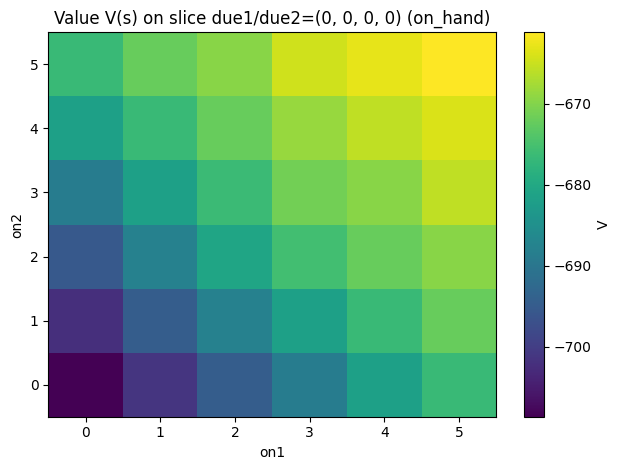

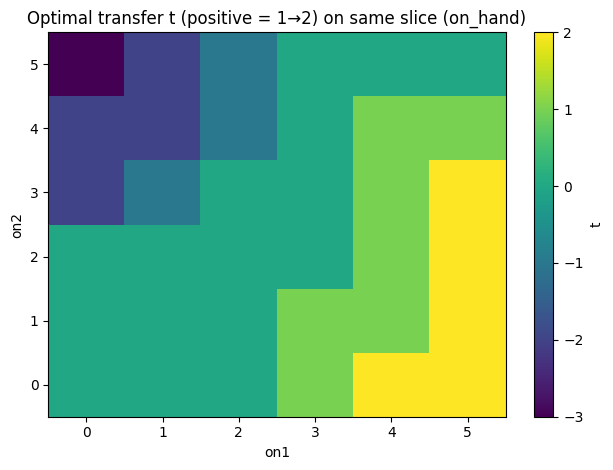

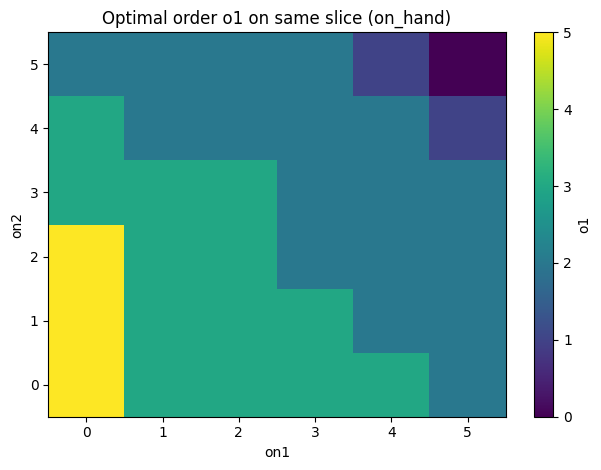

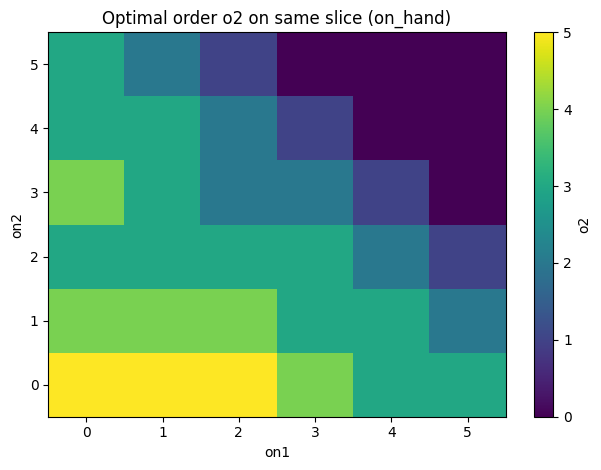

In [21]:
def slice_df(df, *, due1_1=0, due2_1=0, due1_2=0, due2_2=0, use="on_hand"):
    """
    use: "on_hand" -> x=on1, y=on2
         "ip"      -> x=ip1, y=ip2
    """
    d = df[
        (df["due1_1"] == due1_1) & (df["due2_1"] == due2_1) &
        (df["due1_2"] == due1_2) & (df["due2_2"] == due2_2)
    ].copy()

    if use == "on_hand":
        x, y = "on1", "on2"
    elif use == "ip":
        x, y = "ip1", "ip2"
    else:
        raise ValueError("use must be 'on_hand' or 'ip'")

    return d, x, y

def heatmap_from_slice(d, x, y, value_col, title):
    piv = d.pivot_table(index=y, columns=x, values=value_col, aggfunc="mean")
    piv = piv.sort_index(axis=0).sort_index(axis=1)

    plt.figure()
    plt.imshow(piv.values, origin="lower", aspect="auto")
    plt.colorbar(label=value_col)
    plt.xticks(ticks=np.arange(piv.shape[1]), labels=piv.columns)
    plt.yticks(ticks=np.arange(piv.shape[0]), labels=piv.index)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def visualize_policy_on_clean_slice(df, *, due1_1=0, due2_1=0, due1_2=0, due2_2=0, use="on_hand"):
    d, x, y = slice_df(df, due1_1=due1_1, due2_1=due2_1, due1_2=due1_2, due2_2=due2_2, use=use)
    if len(d) == 0:
        print("No states found for that slice.")
        return

    heatmap_from_slice(d, x, y, "V", f"Value V(s) on slice due1/due2={(due1_1,due2_1,due1_2,due2_2)} ({use})")
    heatmap_from_slice(d, x, y, "t", f"Optimal transfer t (positive = 1→2) on same slice ({use})")
    heatmap_from_slice(d, x, y, "o1", f"Optimal order o1 on same slice ({use})")
    heatmap_from_slice(d, x, y, "o2", f"Optimal order o2 on same slice ({use})")

# df = results_to_dataframe(opt_vf_vi, opt_policy_vi)
visualize_policy_on_clean_slice(df, due1_1=0, due2_1=0, due1_2=0, due2_2=0, use="on_hand")


In [22]:
from itertools import product
from rl.dynamic_programming import value_iteration_result

def run_one(mdp_kwargs, gamma=0.95):
    t0 = time.perf_counter()
    mdp = TwoStoresInventoryMDP(**mdp_kwargs)
    build_time = time.perf_counter() - t0

    t1 = time.perf_counter()
    opt_vf, opt_pi = value_iteration_result(mdp, gamma=gamma)
    solve_time = time.perf_counter() - t1

    df = results_to_dataframe(opt_vf, opt_pi)

    # A tiny “policy summary” on the clean slice:
    clean = df[(df.due1_1==0)&(df.due2_1==0)&(df.due1_2==0)&(df.due2_2==0)]
    summary = {
        "mean_o1_clean": float(clean["o1"].mean()) if len(clean) else np.nan,
        "mean_o2_clean": float(clean["o2"].mean()) if len(clean) else np.nan,
        "mean_abs_t_clean": float(clean["t"].abs().mean()) if len(clean) else np.nan,
        "frac_transfer_nonzero_clean": float((clean["t"] != 0).mean()) if len(clean) else np.nan,
    }

    row = {
        **mdp_kwargs,
        "build_time_s": build_time,
        "solve_time_s": solve_time,
        **summary,
    }
    return row, mdp, opt_vf, opt_pi, df

def make_small_grid():
    """
    16 runs:
    - small capacities
    - vary imbalance in demands, stockout penalty, and fixed costs
    """
    capacities = [(3,3), (5,5)]              
    lambdas = [(2.0,2.0), (2.0,4.0), (4.0,2.0)] # balanced + two imbalanced
    pvals = [5.0, 10.0]                         # stockout severity
    fixed = [(0.0, 0.0), (2.0, 1.0)]            # (K1, K2)

    base = dict(h1=1.0, h2=1.0)

    grid = []
    for (C1,C2), (lam1,lam2), p, (K1,K2) in product(capacities, lambdas, pvals, fixed):
        grid.append(dict(
            C1=C1, C2=C2,
            lambda1=lam1, lambda2=lam2,
            p1=p, p2=p,
            K1=K1, K2=K2,
            **base
        ))

    # That is 2*3*2*2 = 24; downsample to ~12–15
    # Keep all (3,3) and a few (5,5)
    small = [g for g in grid if g["C1"]==3]
    medium = [g for g in grid if g["C1"]==5][:4]
    return small + medium  # 12 + 4 = 16 runs

def run_grid(grid, gamma=0.95, visualize_first_k=2):
    results = []
    artifacts = []  # optionally keep dfs/policies for later
    for i, kwargs in enumerate(grid):
        row, mdp, vf, pi, df = run_one(kwargs, gamma=gamma)
        results.append(row)
        artifacts.append((kwargs, mdp, vf, pi, df))

        if i < visualize_first_k:
            print(f"\n=== Run {i+1}/{len(grid)} params: {kwargs} ===")
            visualize_policy_on_clean_slice(df, use="on_hand")

    return pd.DataFrame(results), artifacts



=== Run 1/16 params: {'C1': 3, 'C2': 3, 'lambda1': 2.0, 'lambda2': 2.0, 'p1': 5.0, 'p2': 5.0, 'K1': 0.0, 'K2': 0.0, 'h1': 1.0, 'h2': 1.0} ===


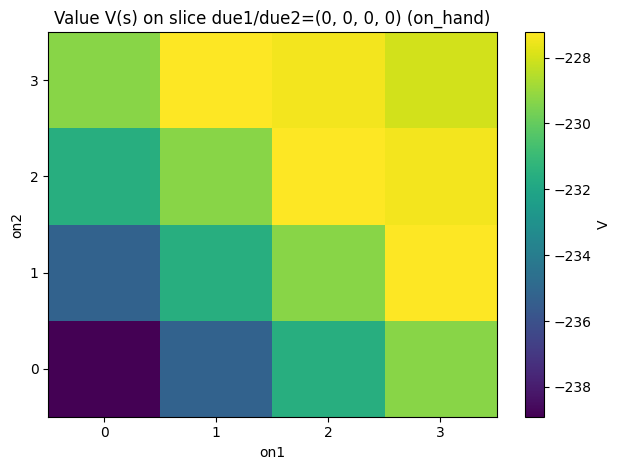

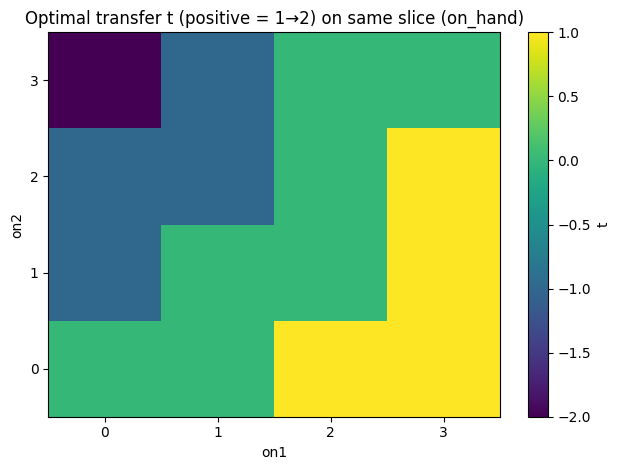

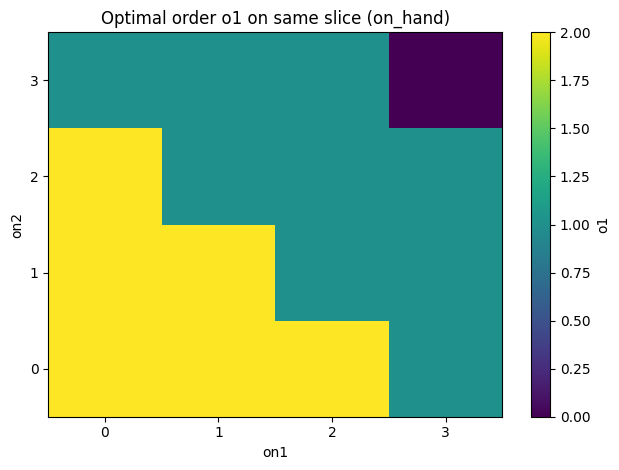

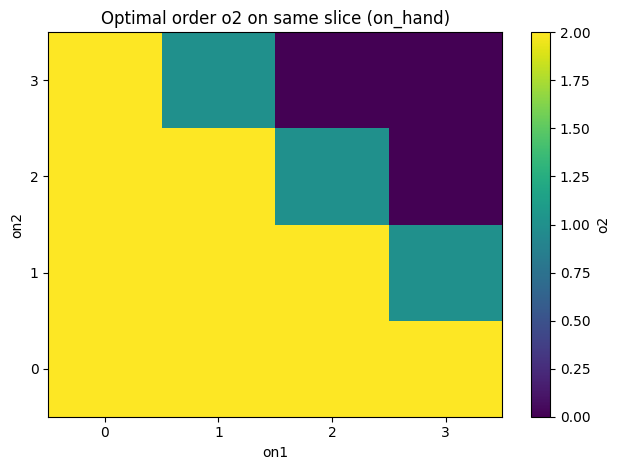


=== Run 2/16 params: {'C1': 3, 'C2': 3, 'lambda1': 2.0, 'lambda2': 2.0, 'p1': 5.0, 'p2': 5.0, 'K1': 2.0, 'K2': 1.0, 'h1': 1.0, 'h2': 1.0} ===


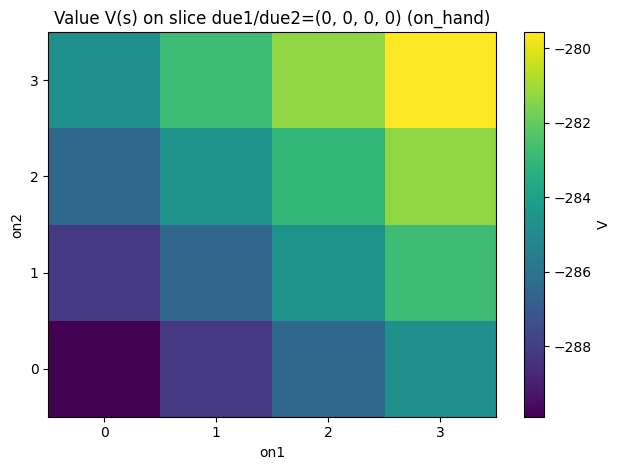

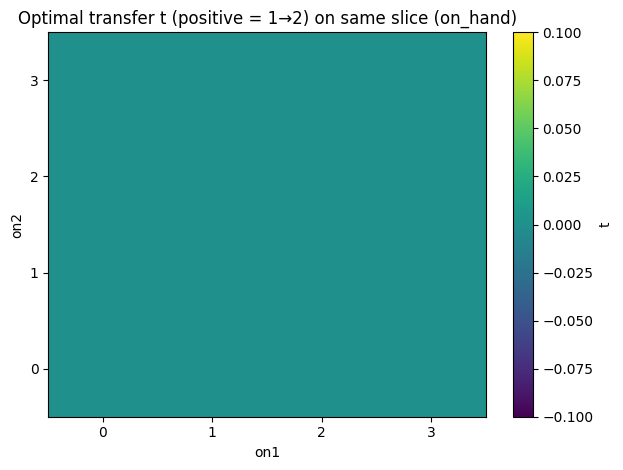

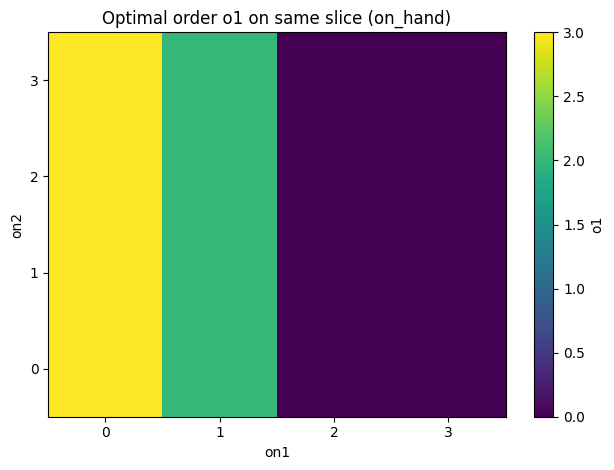

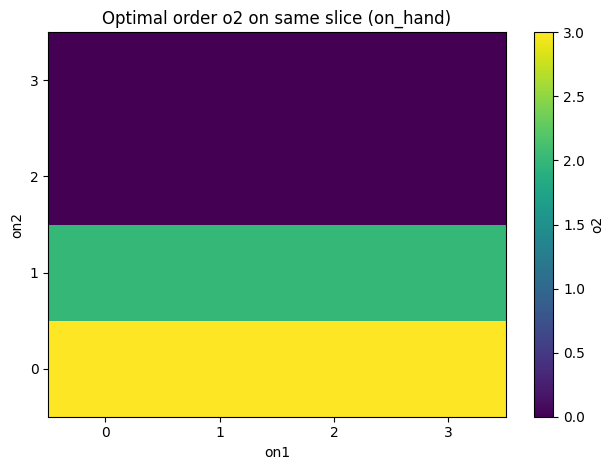

,C1,C2,lambda1,lambda2,p1,p2,K1,K2,h1,h2,build_time_s,solve_time_s,mean_o1_clean,mean_o2_clean,mean_abs_t_clean,frac_transfer_nonzero_clean
15,5,5,2.0,2.0,10.0,10.0,2.0,1.0,1.0,1.0,2.350130,252.071525,2.472222,2.500000,0.722222,0.444444
13,5,5,2.0,2.0,5.0,5.0,2.0,1.0,1.0,1.0,2.149306,244.929692,2.250000,2.416667,0.666667,0.416667
14,5,5,2.0,2.0,10.0,10.0,0.0,0.0,1.0,1.0,6.572623,229.313324,2.222222,2.222222,0.972222,0.694444
12,5,5,2.0,2.0,5.0,5.0,0.0,0.0,1.0,1.0,4.997062,221.322685,2.055556,2.388889,0.972222,0.694444
6,3,3,2.0,4.0,10.0,10.0,0.0,0.0,1.0,1.0,0.077842,10.567415,1.312500,1.625000,0.625000,0.562500
7,3,3,2.0,4.0,10.0,10.0,2.0,1.0,1.0,1.0,0.078537,10.146775,2.000000,1.000000,0.625000,0.375000
2,3,3,2.0,2.0,10.0,10.0,0.0,0.0,1.0,1.0,0.090217,9.442505,1.375000,1.625000,0.625000,0.562500
1,3,3,2.0,2.0,5.0,5.0,2.0,1.0,1.0,1.0,0.073543,8.512892,1.250000,1.250000,0.000000,0.000000
8,3,3,4.0,2.0,5.0,5.0,0.0,0.0,1.0,1.0,0.074557,8.505866,1.625000,1.312500,0.625000,0.562500
3,3,3,2.0,2.0,10.0,10.0,2.0,1.0,1.0,1.0,0.090904,8.009862,1.437500,1.562500,0.312500,0.250000


In [23]:
grid = make_small_grid()
results_df, artifacts = run_grid(grid, gamma=0.95, visualize_first_k=2)

# Sort by runtime
results_df.sort_values("solve_time_s", ascending=False).head(10)


Optimal policy analysis: The qualitative structure of the optimal policy is consistent with the model parameters and basic cost tradeoffs. Larger stockout penalties increase the expected cost of unmet demand, so the policy responds by ordering more and maintaining higher inventory levels to reduce shortage risk. Differences in demand rates across stores generate the expected asymmetry: the higher demand location carries more inventory and tends to reorder more frequently since its stock is depleted faster on average. Transfer decisions follow the same logic. When transfer costs are small, moving inventory between stores is often worthwhile because it helps balance inventory against demand variability. As transfer costs increase, the policy becomes more selective and transfers occur less often. The policy behaves as one would expect from a cost minimization perspective, trading off holding costs against the risk and cost of stockouts while accounting for the expense of adjusting inventory through orders and transfers.

## Question 3: Dynamic Price Optimization (Led by Lucas Tellez)

You own a supermarket, and you are $T$ days away from Halloween 🎃. You have just received $M$ Halloween masks from your supplier. You want to dynamically set the selling price of the Halloween masks at the start of each day in a manner that maximizes your **Expected Total Sales Revenue** for Halloween masks this season (assume no one will buy Halloween masks after Halloween).

Assume that for each of the $T$ days, you are required to select a price for that day from one of $N$ prices $p_1, p_2, \dots, p_N \in \mathbb{R}$, and that price is the selling price for all masks on that day. Assume that the customer demand for the number of Halloween masks on any day is governed by a Poisson probability distribution with mean $\lambda_i \in \mathbb{R}$ if you select that day’s price to be $p_i$ (where $i$ is a choice among $1, 2, \dots, N$).

Note that on any given day, the demand could exceed the number of Halloween masks you have in the store, in which case the number of masks sold on that day will be equal to the number of Halloween masks you had at the start of that day.

We spoke about this example in class - referencing the slides here (if needed) could be helpful!

---

### Subquestions

#### Part (A): Bellman Optimality Equation

Write the **Bellman Optimality Equation** customized to this Markov Decision Process (MDP). Essentially, you need to express the **Optimal Value Function** $v_*$ recursively based on taking the best action in the current state and based on the subsequent random customer demand that would produce the appropriate reward and take you to the next state.

**Note**: The probability mass function of a Poisson distribution with mean $\lambda \in \mathbb{R}$ is given by:

$$
f(k) = \frac{e^{-\lambda} \lambda^k}{k!}, \quad k = 0, 1, 2, \dots
$$

---

#### Part (B): Boundary Conditions

To be able to solve the $v_*$ recursion, you need to know the values of $v_*$ for the boundary case (boundary states). Write down the boundary case(s) for the $v_*$ recursion.

---

#### Part (C): Numerical Solution

You can solve this $v_*$ recursion (hence, solve for the **Optimal Policy** $\pi_*$) with a numerical recursive algorithm (essentially a special form of Dynamic Programming algorithm customized to this problem). 

Write Python code for this algorithm that would enable you to dynamically set the selling price at the start of each day. Clearly define the inputs and outputs of your algorithm with their types (`int`, `float`, `List`, `Mapping`, etc.).

---


### Part (A) Answer

The state is a tuple $(t,m)$ where $t \in \{1,...,T\}$ is the day and $m \in \{1,...,M\}$ is the number of masks left in inventory. The action is of course just the price $p_i \in \{p_1,...,p_N\}$. Just as is done in part b, we can express the expected reward as below leading to the Bellman Optimality Equation for any $t < T$ $$V^*(t,m) = \max_{i=1}^N \bigg[p_i\lambda_i F(m-2;\lambda_i) + m p_i (1-F(m-1;\lambda_i)) + \sum_{k=0}^{m-1} \frac{e^{-\lambda_i}\lambda_i^k}{k!}V^*(t+1,m-k) \bigg]$$ where $S_i$ is poisson with parameter $\lambda_i$ and $F(k;\lambda_i) = P(S_i \leq k)$ is its CDF.

### Part (B) Answer

Since it terminates on day $T$, we know that $$V^*(T,m) = \max_{i=1}^N \mathcal R(T,m,p_i) = \max_{i=1}^N\mathbb E[p_i\min\{m,S_i\}] = \max_{i=1}^N\bigg[ p_i\sum_{k=0}^{m-1}\frac{ke^{-\lambda_i}\lambda_i^k}{k!} + p_im\sum_{k=m}^\infty \frac{e^{-\lambda_i}\lambda_i^k}{k!}\bigg] = $$ $$\max_{i=1}^N\bigg[ p_i\lambda_i\sum_{k=0}^{m-2}\frac{e^{-\lambda_i}\lambda_i^k}{k!} + p_im\sum_{k=m}^\infty \frac{e^{-\lambda_i}\lambda_i^k}{k!}\bigg] = \max_{i=1}^N \bigg[ p_i\lambda_i F(m-2;\lambda_i) + m p_i (1-F(m-1;\lambda_i)) \bigg]$$ 

### Part (C) Answer

In [109]:
def BackInduct(M: int, T: int, p: npt.NDArray[np.float64], lambs: npt.NDArray[np.float64]):
    assert p.shape == lambs.shape
    N = len(p)
    assert N > 0
    V = np.empty((M, T), dtype=float)
    Pi = np.empty((M, T), dtype=int)
    Ms = np.arange(M)
    R = np.vstack([ p[i] * lambs[i] * poisson.cdf(Ms - 2, lambs[i]) + Ms * p[i] * poisson.sf(Ms - 1, lambs[i]) for i in range(N)])
    V[:, -1] = np.max(R, axis=0)
    Pi[:, -1] = np.argmax(R, axis=0)
    ks = np.arange(M)
    PMF = np.vstack([poisson.pmf(ks, lambs[i]) for i in range(N)])
    for t in trange(T - 2, -1, -1):
        Vnext = V[:, t + 1]
        Q = np.empty((N, M), dtype=float)
        v0 = Vnext[0]
        for i in range(N):
            Q[i] = np.convolve(PMF[i], Vnext, mode="full")[:M] - PMF[i] * v0 + R[i]
        V[:, t] = np.max(Q, axis=0)
        Pi[:, t] = np.argmax(Q, axis=0)
    return V, Pi


100%|██████████| 30/30 [00:03<00:00,  8.16it/s]


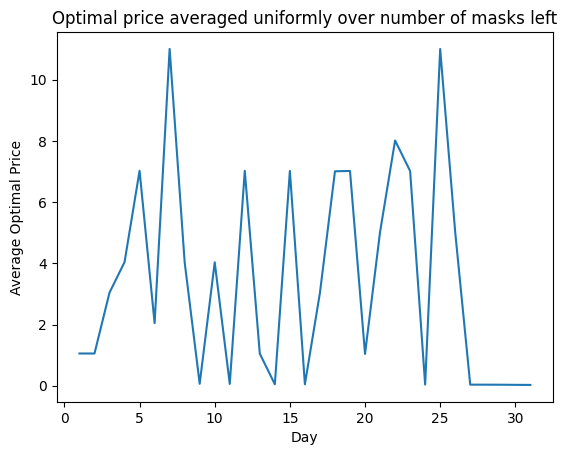

In [110]:
V,Pi = BackInduct(5000,31,np.arange(1,15),1.0/np.arange(1,15))
plt.plot(np.arange(1,32),Pi.mean(axis=0))
plt.ylabel("Average Optimal Price")
plt.xlabel("Day")
plt.title("Optimal price averaged uniformly over number of masks left")
plt.show()

## Question 4: Risk-Aversion and Utility Optimization under CARA Utility (Led by Jordan Rothkowitz)

You are tasked with analyzing the behavior of an investor who seeks to maximize their utility under **CARA Utility**. The investor has wealth $W$ and the CARA utility function:

$$
U(W) = \frac{1 - e^{-aW}}{a}, \quad a > 0,
$$

where $a$ represents the investor's **risk aversion**.

The investor allocates their wealth between:
1. A **riskless asset** with a fixed return $r$, and
2. A **risky asset** with return $R \sim \mathcal{N}(\mu, \sigma^2)$

The investor allocates a fraction $\pi$ of their wealth to the risky asset and $(1 - \pi)$ to the riskless asset. The wealth $W$ after one year is given by:

$$
W = (1 + r)(1 - \pi) + (1 + R)\pi.
$$

The goal is to analyze the investor’s optimal allocation $\pi$ to the risky asset and compute key risk-related quantities.

---

### Subquestions

#### Part (A): Expected Utility and Certainty-Equivalent Wealth

1. Derive the expression for the **expected utility** $\mathbb{E}[U(W)]$, using the given CARA utility function and assuming $R \sim \mathcal{N}(\mu, \sigma^2)$.
2. Using a Taylor expansion, approximate the **certainty-equivalent wealth** $W_{CE}$ up to second-order terms.

---

#### Part (B): Optimal Portfolio Allocation

Derive the optimal fraction $\pi^*$ of wealth to be allocated to the risky asset such that the **expected utility** $\mathbb{E}[U(W)]$ is maximized. Express $\pi^*$ in terms of $a$, $\mu$, $r$, and $\sigma^2$.

---

#### Part (C): Risk Premium

1. Using the results from Part (A), calculate the **absolute risk premium** $\pi_A = \mathbb{E}[W] - W_{CE}$.
2. Verify that $\pi_A \approx \frac{a \pi^2 \sigma^2}{2}$ for small $\sigma^2$.

---

#### Part (D): Numerical Calculations and Interpretation

Given the parameters $r = 0.02$, $\mu = 0.08$, $\sigma^2 = 0.04$, and $a = 3$:
1. Compute the optimal allocation $\pi^*$.
2. Calculate the certainty-equivalent wealth $W_{CE}$.
3. Compute the absolute risk premium $\pi_A$.
4. Interpret the results and discuss how changes in $a$ and $\sigma^2$ affect the risk premium and portfolio allocation.

---

#### Part (E): Expected Utility under Uniform Distribution

Now assume that the return of the risky asset, $R$, is no longer normally distributed. Instead, $R \sim \text{Uniform}[\alpha, \beta]$, where $\alpha$ and $\beta$ are the lower and upper bounds of the distribution, respectively.

1. Derive the new expression for the **expected utility** $\mathbb{E}[U(W)]$. Make sure to simplify your result as much as possible, and ensure that it explicitly depends on $a$, $\pi$, $\alpha$, $\beta$, and $r$.

**Hint**: Use the fact that if $W \sim \text{Uniform}[w_{\text{min}}, w_{\text{max}}]$, then:

$$
\mathbb{E}[g(W)] = \frac{1}{w_{\text{max}} - w_{\text{min}}} \int_{w_{\text{min}}}^{w_{\text{max}}} g(W) \, dW.
$$

---

### Part (A) Answer

First, we'll simplify $W$: 
$$
\begin{align*}
W &= (1+r)(1-\pi)+(1+R)\pi\\
&= (1+r)-\pi(1+r)+\pi+\pi R\\
&= (1+r)+\pi(R-r)
\end{align*}
$$
Then, since $R\sim\mathcal{N}(\mu,\sigma^2)$, we have 
$$
R-r\sim\mathcal{N}(\mu-r,\sigma^2),
$$
and thus 
$$
W\sim \mathcal{N}((1+r)+\pi(\mu -r), \pi^2\sigma^2).
$$
via properties of the Gaussian distribution. Next we will compute $\mathbb{E}[U(W)]$:
$$
\begin{align*}
\mathbb{E}[U(W)] &= \mathbb{E}\left[\frac{1-e^{-aW}}{a}\right]\\
&= \mathbb{E}\left[\frac1a - \frac{e^{-aW}}{a}\right]\\
&= \frac1a - \frac1a \mathbb{E}[e^{-aW}]\\
&= \frac{1-\mathbb{E}[e^{-aW}]}{a}
\end{align*}
$$
Note that the exponential moment for a Gaussian $X\sim\mathcal{N}(\mu,\sigma^2)$ is given by $\mathbb{E}[e^{tX}]=\exp(t\mu + \frac12 t^2\sigma^2)$, so taking $W$ and letting $t=-a$, this yields
$$
\begin{align*}
\mathbb{E}[U(W)] &= \frac{1-\exp(-a((1+r)+\pi(\mu -r))+\frac12 a^2\pi^2\sigma^2)}{a}
\end{align*}
$$
Now we will use a Taylor expansion to approximate the certainty-equivalent wealth $W_{CE}$ up to second-order terms. By definition, $W_{CE}$ satisfies 
$$
U(W_{CE}) = \mathbb{E}[U(W)].
$$
Expanding $U(W)$ around $\bar{W}:=\mathbb{E}[W]$:
$$
\begin{align*}
U(W) &\approx U(\bar{W})+U'(\bar{W})(W-\bar{W})+\frac12 U''(\bar{W})(W-\bar{W})^2\\
\mathbb{E}[U(W)] &\approx U(\bar{W}) + U'(\bar{W})\mathbb{E}[W-\bar{W}]+\frac12 U''(\bar{W})\mathbb{E}[(W-\bar{W})^2]
\end{align*}
$$
since $U(\bar{W}), U'(\bar{W}), U''(\bar{W})$ are deterministic and do not depend on $W$. Then
$$
\begin{align*}
\mathbb{E}[U(W)] &\approx U(\bar{W}) + U'(\bar{W})(\mathbb{E}[W]-\bar{W})+\frac12 U''(\bar{W})\text{Var}(W)\\
&= U(\bar{W}) +\frac12 U''(\bar{W})\text{Var}(W)
\end{align*}
$$
since $\mathbb{E}[W]=\bar{W}$.

Now, we need to expand $U(W_{CE})$ around $\bar{W}$ to the first order, equate the two expressions, then solve for $W_{CE}$. 
$$
\begin{align*}
U(W_{CE}) &\approx U(\bar{W})+U'(\bar{W})(W_{CE}-\bar{W})\\
U(\bar{W})+U'(\bar{W})(W_{CE}-\bar{W}) &\approx U(\bar{W})+\frac12 U''(\bar{W})\text{Var}(W)\\
U'(\bar{W})(W_{CE}-\bar{W}) &\approx \frac12 U''(\bar{W})\text{Var}(W)\\
W_{CE} &\approx \bar{W}+\frac12\frac{U''(\bar{W})}{U'(\bar{W})}\text{Var}(W).
\end{align*}
$$
What remains is to plug the CARA derivatives into the absolute risk aversion $A(x)=-\frac{U''(x)}{U'(x)}$. We have 
$$
\begin{align*}
U(W) &= \frac{1 - e^{-aW}}{a},\\
U'(W) &= e^{-aW}\\
U''(W) &= -ae^{-aW}\\
A(x) &= -\frac{U'(W)}{U''(W)} = a
\end{align*}
$$
Thus 
$$
\begin{align*}
W_{CE} &\approx \bar{W}-\frac12 a\text{Var}(W)\\
W_{CE} &\approx (1+r)+\pi(\mu -r) - \frac12 a\pi^2\sigma^2
\end{align*}
$$

### Part (B) Answer

In part (a), we found
$$
W=(1+r)+\pi(R-r).
$$
So
$$
\mathbb{E}[W]=(1+r)+\pi(\mu-r), \qquad \mathrm{Var}(W)=\pi^2\sigma^2
$$
and
$$
W_{CE} = \mathbb{E}[W] - \frac{a}{2}\mathrm{Var}(W)
= (1+r)+\pi(\mu-r)-\frac{a}{2}\pi^2\sigma^2.
$$

Note that maximizing expected utility is equivalent to maximizing $W_{CE}$ because $U(\cdot)$ is strictly increasing and the CE is defined so that $U(W_{CE})=\mathbb{E}[U(W)]$. 

So we maximize the quadratic function of $\pi$:
$$
\argmax_{\pi}\ \Big[(1+r)+\pi(\mu-r)-\frac{a}{2}\pi^2\sigma^2\Big] = \argmax_{\pi}\ \Big[\pi(\mu-r)-\frac{a}{2}\pi^2\sigma^2\Big].
$$

Now we'll differentiate and set equal to 0 as in single variable calculus. Let
$$
g(\pi)=\pi(\mu-r)-\frac{a}{2}\pi^2\sigma^2.
$$
Then
$$
g'(\pi)=(\mu-r)-a\sigma^2\pi.
$$
Set $g'(\pi)=0$:
$$
(\mu-r)-a\sigma^2\pi^*=0
\quad\Rightarrow\quad
\boxed{\pi^*=\frac{\mu-r}{a\sigma^2}.}
$$
Assuming ($\pi$) is unconstrained.

As a santiy check, the second derivative is
$$
g''(\pi)=-a\sigma^2<0
$$
so we've found a maximum.



### Part (C) Answer

Again, in part (a), we calculated $\mathbb{E}[W]=(1+r)+\pi(\mu-r)$, $\mathrm{Var}(W)=\pi^2\sigma^2$, and $W_{CE}\approx \mathbb{E}[W] - \frac{a}{2}\mathrm{Var}(W) = (1+r)+\pi(\mu-r)-\frac{a}{2}\pi^2\sigma^2$. Thus 
$$
\begin{align*}
\pi_A &= \mathbb{E}[W]-W_{CE}\\
&\approx \mathbb{E}[W]-(\mathbb{E}[W] - \frac{a}{2}\mathrm{Var}(W))\\
&= \frac{a}{2}\mathrm{Var}(W)\\
&= \frac{a}{2}\pi^2\sigma^2
\end{align*}
$$

To verify that $\pi_A \approx \frac{a}{2}\pi^2\sigma^2$ for small $\sigma^2$, recall that the Taylor expansion argument from part (a) gave us that the first correction to $W_{CE}$ away from $\mathbb{E}[W]$ comes from the quadratic term, which is proportional to the variance $\mathrm{Var}(W)=\pi^2\sigma^2$. Thus the leading-order term in $\pi_A$ is $\pi_A=\mathbb{E}[W]-W_{CE}\approx \frac a2 \pi^2\sigma^2$ as $\sigma^2\rightarrow 0$. Keeping higher order terms from the Taylor series would contribute $O(\sigma^4)$ which is negligible for small $\sigma^2$.

### Part (D) Answer

With the given parameters $r = 0.02$, $\mu = 0.08$, $\sigma^2 = 0.04$, and $a = 3$, we compute
$$
\begin{align*}
\pi^* &= \frac{\mu-r}{a\sigma^2}\\
&= \frac{0.08-0.02}{3\cdot 0.04}\\
&= 0.5\\
W_{CE} &\approx (1+r)+\pi(\mu -r) - \frac12 a\pi^2\sigma^2 \\
&= (1+0.02)+0.5(0.08-0.02)-\frac12 3\cdot 0.5^2\cdot 0.04\\
&= 1.035\\
\pi_A &= \frac{a}{2}\pi^2\sigma^2\\
&= \frac32 \cdot 0.5^2\cdot 0.04\\
&= 0.015
\end{align*}
$$

The numerical results illustrate the economic meaning of CARA utility and risk aversion. The optimal allocation $ \pi^* = 0.5 $ indicates that the investor chooses to place half of their wealth in the risky asset and half in the riskless asset. Although the risky asset offers a higher expected return than the riskless asset, the investor does not invest fully in it because uncertainty reduces utility. The expected terminal wealth under this allocation is $ \mathbb{E}[W] = 1.05 $, corresponding to a 5% expected gain on the initial wealth. However, the certainty-equivalent wealth is lower, $ W_{CE} = 1.035 $, meaning the investor is indifferent between the risky strategy and receiving a guaranteed 3.5% return. The difference between these quantities, the absolute risk premium $ \pi_A = 0.015 $, represents the compensation the investor requires for bearing risk. Economically, this value measures the utility cost of uncertainty.

The formulas also clarify how preferences and market uncertainty influence decisions. An increase in the risk-aversion parameter $ a $ reduces the optimal allocation to the risky asset, since a more risk-averse investor is less willing to tolerate variability in outcomes. Greater risk aversion also raises the risk premium required for any fixed risky position, reflecting a stronger dislike of uncertainty. Similarly, an increase in return variance $ \sigma^2 $ makes the risky asset less attractive, lowering the optimal risky allocation because each unit of exposure now carries more risk. Higher variance also increases the risk premium associated with any fixed exposure.

### Part (E) Answer

Recall from previous parts that $W=(1+r)+\pi(R-r)$ and define the constant $c:=(1+r)-\pi r$. Then 
$$
W=c+\pi R.
$$
Since $R\sim \mathrm{Uniform}[\alpha, \beta]$, $W$ is uniform on the interval obtained by mapping $[\alpha, \beta]$ through $R \mapsto c+\pi R$. Then the endpoints are 
$$
w_{\min}=c+\pi a, \qquad w_{\max}=c+\pi \beta.
$$
Now we can compute $\mathbb{E}[U(W)]$ using the uniform integral from the hint:
$$
\begin{align*}
\mathbb{E}[U(W)] &= \frac{1}{w_{\max}-w_{\min}}\int_{w_{\min}}^{w_{\max}} \frac{1-e^{-aW}}{a}dW\\
&= \frac{1}{w_{\max}-w_{\min}}\left( \frac1a \int_{w_{\min}}^{w_{\max}} 1dW-\frac1a \int_{w_{\min}}^{w_{\max}} e^{-aW}dW \right)\\
&= \frac{1}{w_{\max}-w_{\min}} \left[ \frac Wa+\frac {e^{-aW}}{a^2} \right]_{w_{\min}}^{w_{\max}}\\
&= \frac{1}{\pi(\beta-\alpha)}\left[ \frac{w_{\max}}{a}-\frac{w_{\min}}{a}+\frac{e^{-a\cdot w_{\max}}}{a^2}-\frac{e^{-a\cdot w_{\min}}}{a^2}\right]\\
&= \frac{1}{\pi(\beta-\alpha)}\left[ \frac{w_{\max}-w_{\min}}{a}+\frac{e^{-a\cdot w_{\max}}- e^{-a\cdot w_{\min}}}{a^2}\right]\\
&= \frac{1}{\pi(\beta-\alpha)}\left[ \frac{\pi(\beta-\alpha)}{a}+\frac{e^{-a\cdot ((1+r)+\pi(\beta-r))}- e^{-a\cdot ((1+r)+\pi(\alpha-r))}}{a^2}\right]\\
&= \boxed{\frac1a +\frac{e^{-a\cdot ((1+r)+\pi(\beta-r))}- e^{-a\cdot ((1+r)+\pi(\alpha-r))}}{a^2\pi(\beta-\alpha)}}
\end{align*}
$$
